# Car Price Prediction Project

# Problem Statement

The objective of this project is to predict the selling price of used cars based on various features such as present price, fuel type, transmission type, kilometers driven, ownership history, and car age.

# Importing packages

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Load the Dataset

In [5]:
df = pd.read_csv("car data.csv")

# Basic operations

Display First Five Rows of the Dataset

In [6]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Display Last Five Rows of the Dataset

In [7]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


Check Dataset Shape

In [8]:
df.shape

(301, 9)

Display Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Statistical Summary of Dataset

In [10]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Check Missing Values

In [11]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

# Display Dataset Columns

In [12]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

# Encode Categorical Features Using Label Encoding

In [13]:
le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Selling_type'] = le.fit_transform(df['Selling_type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

# Create Car Age Feature

In [14]:
df['Car_Age'] = 2026 - df['Year']

# Drop Unnecessary Columns

In [15]:
df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

# Define Features and Target Variable

In [16]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Split Dataset into Training and Testing Sets

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize Linear Regression Model

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Generate Predictions on Test Data

In [19]:
y_pred = model.predict(X_test)

# Evaluate Model Performance

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 1.221932362175385
Mean Squared Error: 3.531579888968638
R2 Score: 0.8466902419663827


# Visualize Actual vs Predicted Car Prices

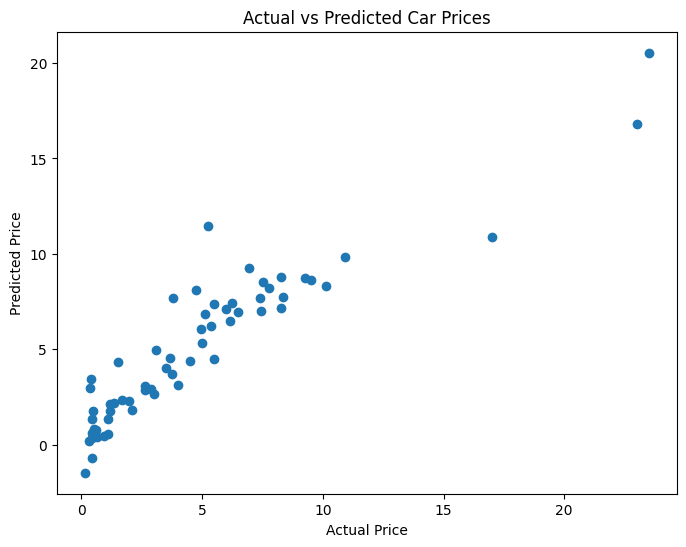

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

# Visualize Distribution of Prediction Errors

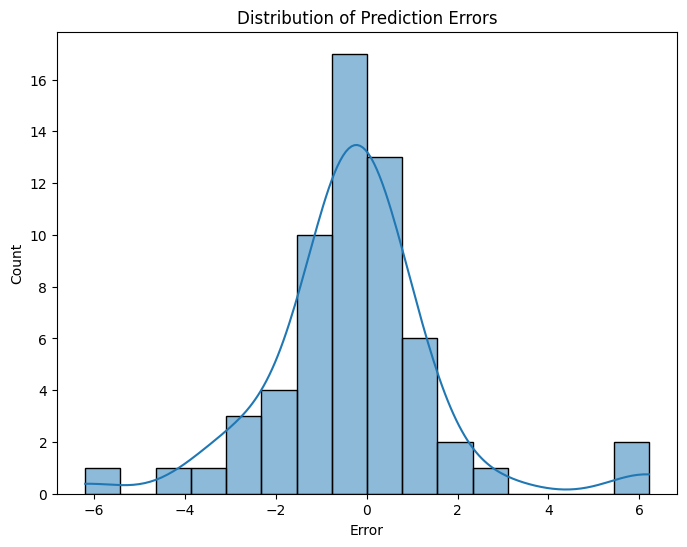

In [22]:
errors = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(errors, kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")

plt.show()

# Analyze Feature Importance Using Model Coefficients

In [23]:
coefficients = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=['Coefficient']
)

print(coefficients)

               Coefficient
Present_Price     0.439871
Driven_kms       -0.000005
Fuel_Type        -1.324534
Selling_type     -1.169683
Transmission     -1.637471
Owner            -0.921467
Car_Age          -0.362731


# Compare Actual and Predicted Price Trends

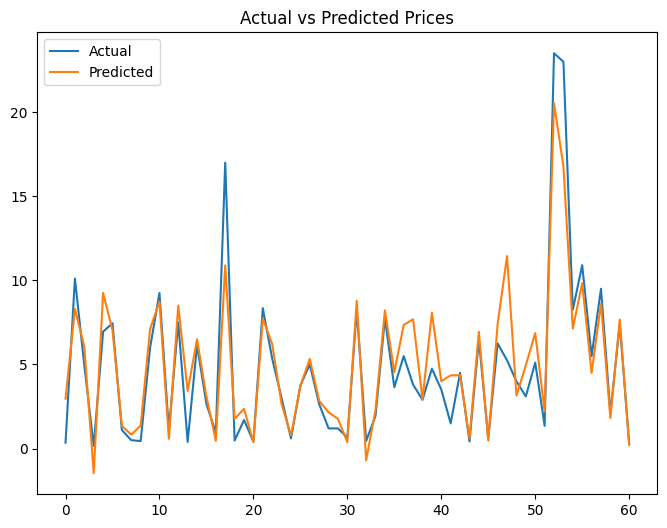

In [24]:
plt.figure(figsize=(8,6))

plt.plot(range(len(y_test.values)), y_test.values, label='Actual')
plt.plot(range(len(y_pred)), y_pred, label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Prices")
plt.show()

# Correlation Heatmap Analysis

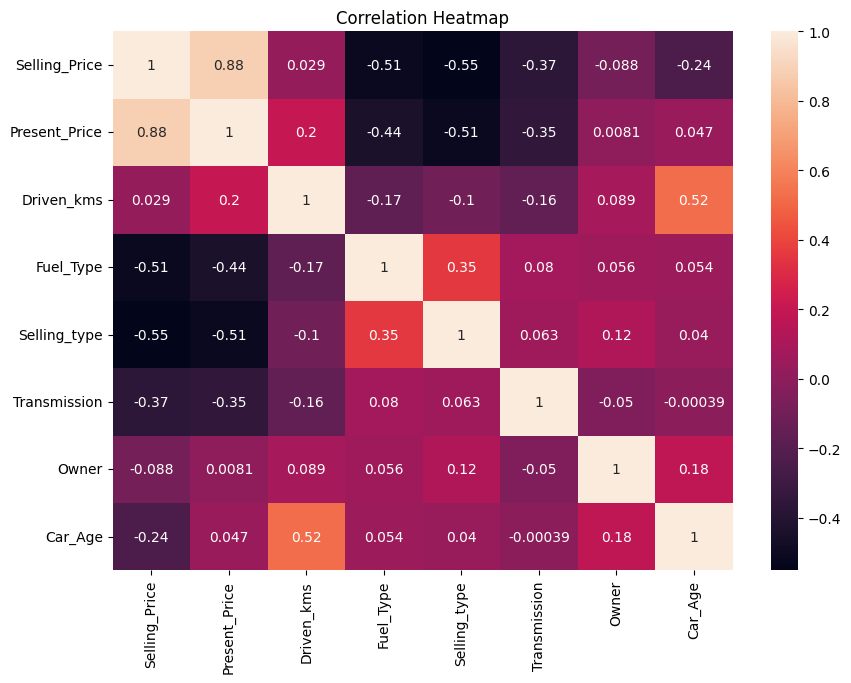

In [25]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

# Analyze Relationship Between Car Age and Selling Price

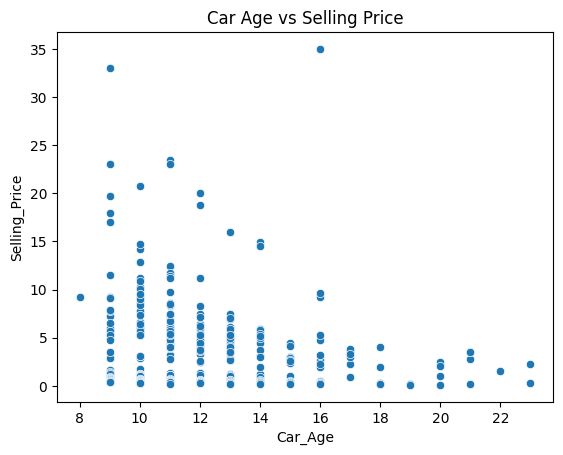

In [26]:
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df)

plt.title("Car Age vs Selling Price")
plt.show()

Observation:
Older cars generally tend to have lower selling prices.

# Visualize Fuel Type Distribution

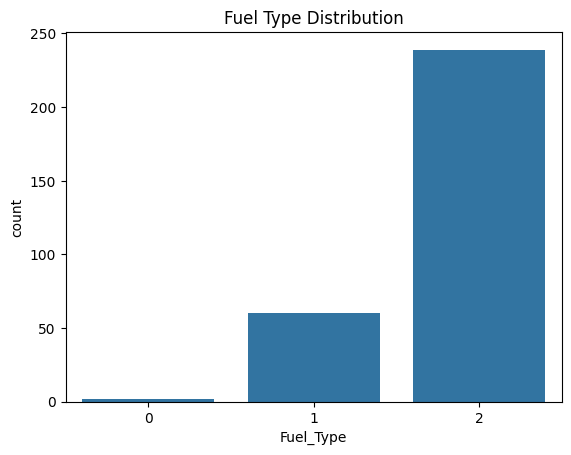

In [27]:
sns.countplot(x='Fuel_Type', data=df)

plt.title("Fuel Type Distribution")
plt.show()

# Detect Outliers in Selling Price

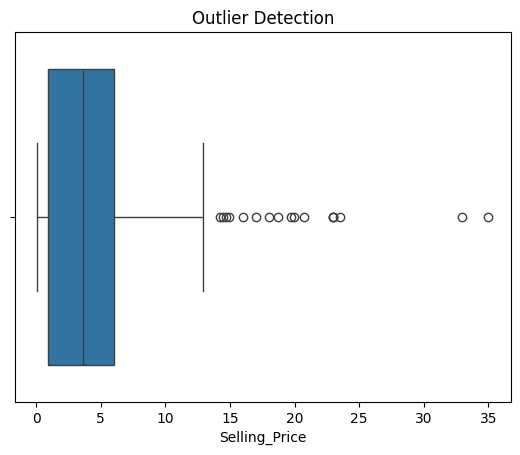

In [28]:
sns.boxplot(x=df['Selling_Price'])

plt.title("Outlier Detection")

plt.show()

# Import Random Forest Regressor

In [29]:
from sklearn.ensemble import RandomForestRegressor

# Train random forest model

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Generate Predictions using Random forest Model
rf_pred = rf.predict(X_test)


# Calculate Random Forest Evaluation Metrics

In [30]:
print("Random Forest R2 Score:", r2_score(y_test, rf_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

Random Forest R2 Score: 0.9592683769360726
Random Forest MAE: 0.6389196721311476


# Compare R2 Scores of Linear Regression and Random Forest Models

In [31]:
print("Linear Regression R2 Score:", r2)
print("Random Forest R2 Score:", r2_score(y_test, rf_pred))

Linear Regression R2 Score: 0.8466902419663827
Random Forest R2 Score: 0.9592683769360726


# Compare Performance of Machine Learning Models

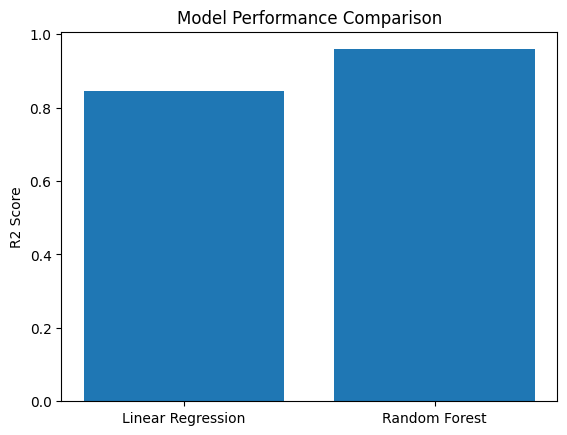

In [32]:
models = ['Linear Regression', 'Random Forest']

scores = [r2, r2_score(y_test, rf_pred)]

plt.bar(models, scores)

plt.ylabel("R2 Score")

plt.title("Model Performance Comparison")

plt.show()

# Visualize Feature Importance Using Random Forest

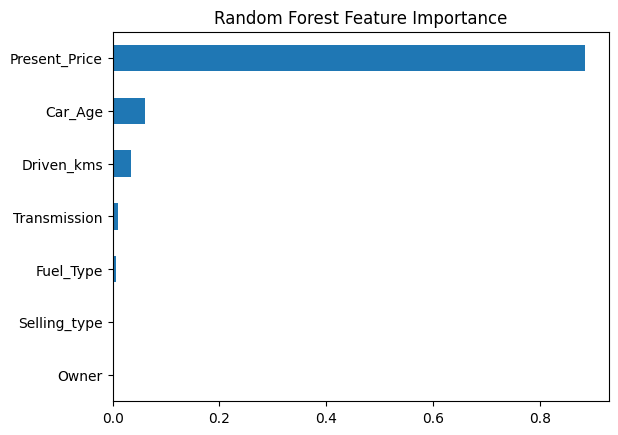

In [33]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

feature_importance.sort_values().plot(kind='barh')

plt.title("Random Forest Feature Importance")

plt.show()

# Perform Cross Validation on Random Forest Model

In [34]:
from sklearn.model_selection import cross_val_score

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print(cv_scores)

print("Average CV Score:", cv_scores.mean())

[ 0.96456679  0.77197177 -1.5820976   0.95054915  0.77342382]
Average CV Score: 0.37568278657938253


# Save the Trained Random Forest Model Using Pickle

In [35]:
import pickle

pickle.dump(rf, open('car_price_model.pkl', 'wb'))

# Display Feature Columns Used in the Model

In [36]:
print(X.columns)

Index(['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type',
       'Transmission', 'Owner', 'Car_Age'],
      dtype='object')


# Predict Car Price Using Sample Input Data

In [37]:
sample_data = [[
    5.5,      # Present_Price
    40000,    # Driven_kms
    1,        # Fuel_Type
    0,        # Selling_type
    0,        # Transmission
    0,        # Owner
    5         # Car_Age
]]

prediction = rf.predict(sample_data)

print("Predicted Car Price:", prediction[0])

Predicted Car Price: 3.827


c:\Users\vishal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


# Conclusion

This project successfully predicts used car prices using machine learning techniques. Data preprocessing, feature engineering, visualization, and regression models were applied. Among the models tested, Random Forest Regressor achieved better performance compared to Linear Regression based on R² score and error metrics.

# Future Scope

- Deploy the model using Streamlit Cloud
- Improve prediction accuracy using XGBoost
- Integrate real-time automobile datasets
- Build a complete web dashboard
- Enhance UI for better user interaction